# Decision Learning Tree 

**Author: Rownak Deb Kabya -22400196**


## Introduction

This Jupyter notebook implements a Decision Learning Tree without using any external libraries for binary attributes. The decision tree is built using a recursive algorithm that selects the best attribute to split the data at each node based on information gain. Then we will visualize the decision tree using a Graphviz.

#### Decision tree learning
The pseudo-code for the decision tree learning algorithm is as follows:
```python
function DT-LEARNING(examples, attributes, parent examples)
    if empty(examples) then return PLURALITY-VAL(parent examples)
    else if all examples have same classification then return the classification
    else if empty(attributes) then return PLURALITY-VAL(examples)
    else
        A ← argmax
            a∈attributes
        IMPORTANCE(a, examples)
        tree ← a new decision tree with root test A
        for vk ∈ A do
            exs ← {e|e ∈ examples ∧ e.A = vk}
            subtree ← DT-LEARNING(exs, attributes − A, examples)
            add a branch to tree with label (A = vk) and subtree subtree
        end for
        return tree
    end if
end function
```

### Training Set
We will first create a training set to test our decision tree learning algorithm. The training set will consist of binary attributes.

In [46]:
import pandas as pd 

data = [
    {'cloud': 0, 'rain': 0, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 0, 'rain': 1, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 1, 'rain': 1, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 1, 'rain': 0, 'Like': 1, 'temp': 0, 'fun': 0},
    {'cloud': 0, 'rain': 0, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 1, 'rain': 1, 'Like': 0, 'temp': 1, 'fun': 0},
    {'cloud': 1, 'rain': 0, 'Like': 0, 'temp': 1, 'fun': 0},
    {'cloud': 0, 'rain': 1, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 1, 'rain': 1, 'Like': 1, 'temp': 0, 'fun': 1},
    {'cloud': 0, 'rain': 0, 'Like': 1, 'temp': 0, 'fun': 0},
    {'cloud': 1, 'rain': 0, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 0, 'rain': 1, 'Like': 1, 'temp': 0, 'fun': 0},
    {'cloud': 1, 'rain': 1, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 0, 'rain': 0, 'Like': 0, 'temp': 1, 'fun': 0},
    {'cloud': 1, 'rain': 0, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 0, 'rain': 1, 'Like': 0, 'temp': 1, 'fun': 1},
    {'cloud': 1, 'rain': 0, 'Like': 0, 'temp': 1, 'fun': 0},
    {'cloud': 0, 'rain': 1, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 1, 'rain': 1, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 0, 'rain': 0, 'Like': 1, 'temp': 0, 'fun': 1},
    {'cloud': 1, 'rain': 0, 'Like': 1, 'temp': 0, 'fun': 0},
    {'cloud': 0, 'rain': 1, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 1, 'rain': 1, 'Like': 0, 'temp': 1, 'fun': 0},
    {'cloud': 0, 'rain': 0, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 1, 'rain': 0, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 0, 'rain': 1, 'Like': 1, 'temp': 0, 'fun': 1},
    {'cloud': 1, 'rain': 1, 'Like': 1, 'temp': 0, 'fun': 1},
    {'cloud': 0, 'rain': 0, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 1, 'rain': 0, 'Like': 1, 'temp': 1, 'fun': 1},
    {'cloud': 0, 'rain': 1, 'Like': 0, 'temp': 1, 'fun': 0},
    {'cloud': 1, 'rain': 1, 'Like': 0, 'temp': 0, 'fun': 0},
    {'cloud': 0, 'rain': 0, 'Like': 0, 'temp': 1, 'fun': 1},
    {'cloud': 1, 'rain': 1, 'Like': 1, 'temp': 1, 'fun': 1}
]

df = pd.DataFrame(data, columns=['cloud', 'rain', 'Like', 'temp', 'fun'])

df

,cloud,rain,Like,temp,fun
0,0,0,0,0,0
1,0,1,1,1,1
2,1,1,1,1,1
3,1,0,1,0,0
4,0,0,1,1,1
5,1,1,0,1,0
6,1,0,0,1,0
7,0,1,0,0,0
8,1,1,1,0,1
9,0,0,1,0,0


In [47]:
import math
from collections import Counter

### Plurality Value
This function returns the most common class label.

In [48]:
def plurality_val(examples, target):
    count = Counter(example[target] for example in examples)
    return count.most_common(1)[0][0]

### Same Classification
This function checks if all examples in the dataset have the same classification.

In [49]:

def all_same_classification(examples, target):
    labels = [example[target] for example in examples]
    return all(label == labels[0] for label in labels)

### Entropy Calculation
Entropy is a measure of uncertainty or impurity in a dataset. It is calculated using the formula:
$ H(S) = -\sum_{i=1}^{c} p_i \log_2(p_i) $

where $ p_i $ is the proportion of examples in class $ i $ and $ c $ is the number of classes.

In [50]:
def entropy(examples, target):
    total = len(examples)
    if total == 0:
        return 0
    count = Counter(example[target] for example in examples)
    return -sum((c/total)*math.log2(c/total) for c in count.values() if c > 0)

### Information Gain

Information gain tells us which attribute splits the data best.
It is calculated using the formula:
$ IG(S, A) = H(S) - \sum_{v \in Values(A)} \frac{|S_v|}{|S|} H(S_v) $

In [51]:
def information_gain(attribute, examples, target):
    total = len(examples)
    if total == 0:
        return 0
    partitions = {0: [], 1: []}
    for example in examples:
        partitions[example[attribute]].append(example)
    weighted_entropy = sum((len(part)/total)*entropy(part, target) for part in partitions.values())
    return entropy(examples, target) - weighted_entropy

### Implementation of the Decision Tree Learning Algorithm
This is the core of the algorithm, directly following the pseudocode.

In [52]:
def dt_learning(examples, attributes, parent_examples, target):
    if not examples:
        return plurality_val(parent_examples, target)
    elif all_same_classification(examples, target):
        return examples[0][target]
    elif not attributes:
        return plurality_val(examples, target)
    else:
        A = max(attributes, key=lambda a: information_gain(a, examples, target))
        tree = {'attribute': A, 'branches': {}}
        for vk in [0, 1]:
            exs = [e for e in examples if e[A] == vk]
            subtree = dt_learning(exs, [attr for attr in attributes if attr != A], examples, target)
            tree['branches'][vk] = subtree
        return tree

### Visualization of the Decision Tree

We will now visualize the decision tree using Graphviz. The tree will be displayed in a hierarchical format, showing the attributes and their corresponding branches.

In [53]:
from graphviz import Digraph

def visualize_tree(tree, dot=None, parent=None, edge_label='', node_id=0):
    if dot is None:
        dot = Digraph()
    current_id = str(node_id)
    if isinstance(tree, dict):
        label = tree['attribute']
        dot.node(current_id, label, shape='ellipse', style='filled', fillcolor="#cfe2f3")
        if parent is not None:
            dot.edge(parent, current_id, label=str(edge_label))
        next_id = node_id + 1
        for value, subtree in tree['branches'].items():
            dot, next_id = visualize_tree(subtree, dot, current_id, str(value), next_id)
        return dot, next_id
    else:
        label = f"Decision: {tree}"
        dot.node(current_id, label, shape='box', style='filled', fillcolor="#f9cb9c")
        if parent is not None:
            dot.edge(parent, current_id, label=str(edge_label))
        return dot, node_id + 1

### Training the Decision Tree
We will train the decision tree using the training set we created earlier.

In [54]:
df = pd.DataFrame(data, columns=['cloud', 'rain', 'Like', 'temp', 'fun'])

examples = df.to_dict(orient='records')
attributes = ['cloud', 'rain', 'Like', 'temp']
target = 'fun'  # You can change this to any column you want to predict

tree = dt_learning(examples, attributes, [], target)



### Predict with the Tree

We will now predict with the trained decision tree.

In [55]:
def predict(tree, sample):
    """
    Predict the label for a given sample using the decision tree.
    :param tree: The decision tree (as built above)
    :param sample: A dict of attribute values, e.g. {'cloud': 0, 'rain': 1, 'Like': 1, 'temp': 0}
    :return: The predicted class/label
    """
    while isinstance(tree, dict):
        attr = tree['attribute']
        value = sample[attr]
        tree = tree['branches'][value]
    return tree

# Example usage:
sample = {'cloud': 1, 'rain': 0, 'Like': 1, 'temp': 1}
predicted = predict(tree, sample)
print("Prediction for sample:", predicted)

Prediction for sample: 1


### Graphviz Visualization

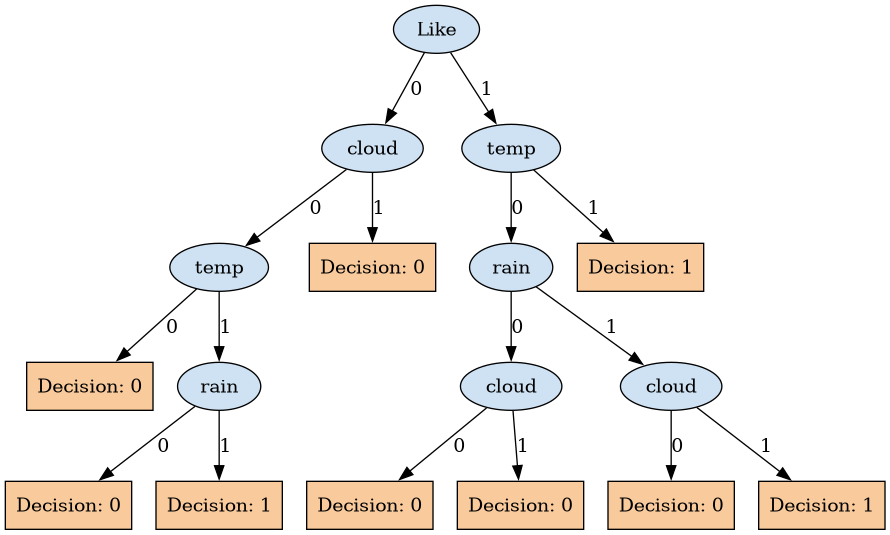

In [56]:
from IPython.display import Image, display

# Render and display in the notebook
dot, _ = visualize_tree(tree)
dot.render('decision_tree', format='png')
display(Image(filename='decision_tree.png'))

## Conclusion
In this notebook, we implemented a Decision Learning Tree from scratch for binary attributes. We built the decision tree using a recursive algorithm based on information gain and visualized it using Graphviz. The decision tree can be used to make predictions on new data points based on the learned structure.